## Load the processed data

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# load processed data
X = np.load("../Data/processed/X.npy")
y = np.load("../Data/processed/y.npy")

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (101163, 250)
Shape of y: (101163,)


## Visualize class imbalance

Class distribution: Counter({np.int64(0): 90347, np.int64(2): 7235, np.int64(1): 2779, np.int64(3): 802})


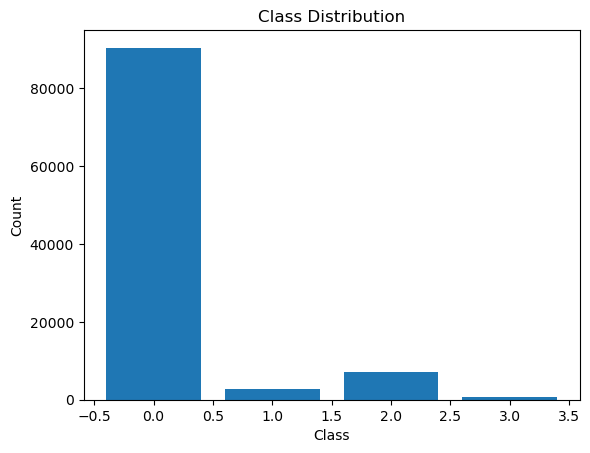

In [17]:
label_counts = Counter(y)

print("Class distribution:", label_counts)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Map labels to human-readable names

In [19]:
label_map = {
    0: "N (Normal)",
    1: "S (Supraventricular)",
    2: "V (Ventricular)",
    3: "Q (Other)"
}

## Example ECG beats per class

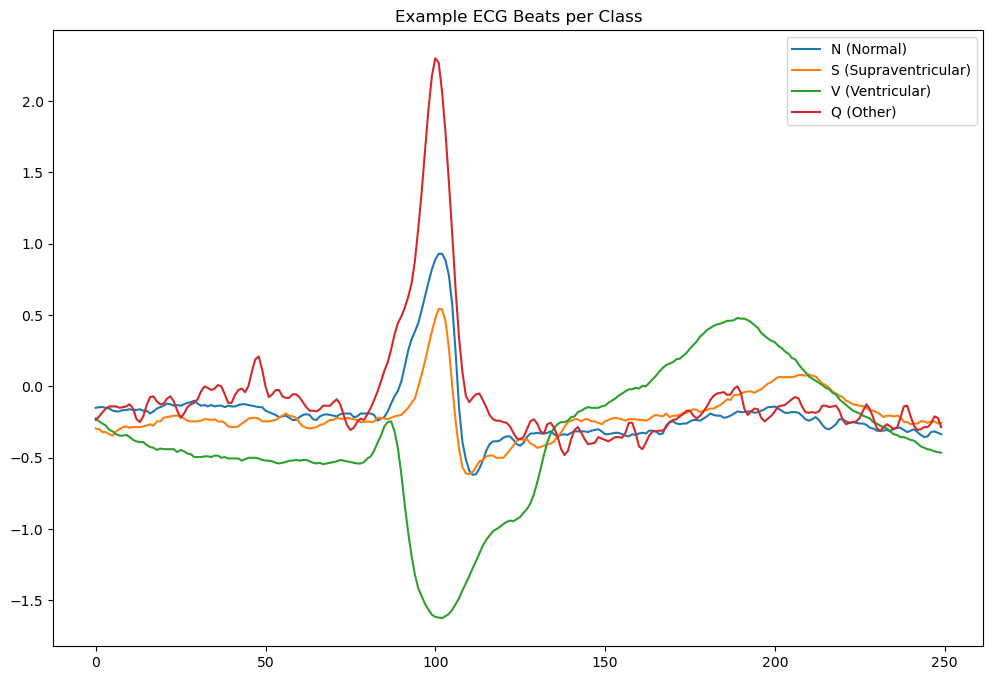

In [20]:
import random

plt.figure(figsize=(12, 8))

for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    sample_idx = random.choice(idx)
    
    plt.plot(X[sample_idx], label=label_map[cls])

plt.legend()
plt.title("Example ECG Beats per Class")
plt.show()

## Check signal quality / noise

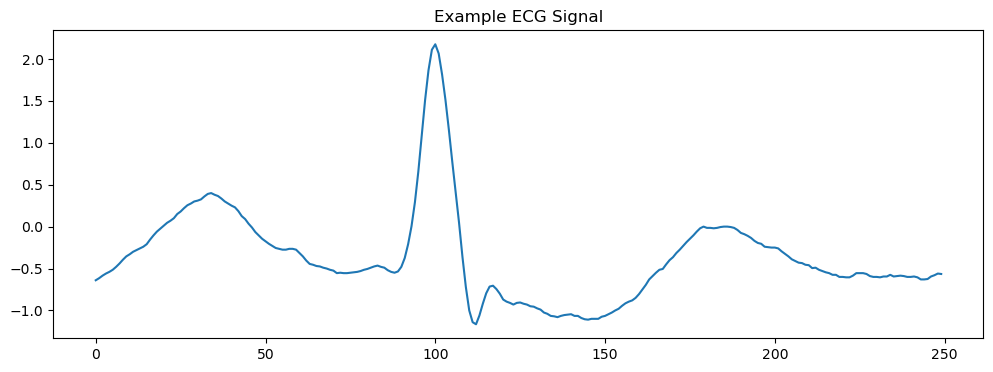

In [21]:
plt.figure(figsize=(12,4))
plt.plot(X[0])
plt.title("Example ECG Signal")
plt.show()

## Compute class weights

In [22]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.2799290513243384), np.int64(1): np.float64(9.100665707088881), np.int64(2): np.float64(3.495611610228058), np.int64(3): np.float64(31.534600997506235)}
